# Predictive Content Engagement Engine: Viral Potential Classification

## Executive Summary
In the short-form video industry, the cost of showing irrelevant content is immediate user churn. This project evaluates an ensemble machine learning pipeline to classify simulated video features, predicting whether content will achieve "High Engagement" (Viral Potential) or "Low Engagement."

**Commercial Objective:** By prioritizing predictive precision and deploying advanced model interpretability via SHAP (SHapley Additive exPlanations), this pipeline explains the algorithmic drivers behind user retention (e.g., audio tempo, watch-time thresholds) directly to content strategy teams.

In [1]:
# Setup and Dependency Installation
import warnings
warnings.filterwarnings('ignore') # Suppresses messy red deprecation warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Clean Installation of Class Imbalance & Interpretability Libraries
try:
    import imblearn
except ImportError:
    !pip install -q imbalanced-learn
finally:
    from imblearn.over_sampling import SMOTE

try:
    import shap
except ImportError:
    !pip install -q shap
finally:
    import shap

# Set visual style for professional graphing
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Environment standardisation complete. Libraries initialised.")

✅ Environment standardisation complete. Libraries initialised.


## 1. Data Ingestion & Simulation
To ensure this notebook is 100% reproducible for reviewers without relying on external CSV files, we simulate a high-fidelity dataset based on the feature distributions of short-form video platforms. We deliberately introduce a class imbalance (with viral videos being rare) to simulate a real-world algorithm environment.

In [2]:
def generate_tiktok_data(n=5000):
    """Simulates short-form video metrics."""
    np.random.seed(101)

    # Base video flow data
    data = {
        'video_duration_sec': np.random.uniform(5, 60, size=n).round(1),
        'audio_tempo_bpm': np.random.normal(loc=120, scale=20, size=n).astype(int),
        'caption_sentiment': np.random.choice([-1, 0, 1], n, p=[0.2, 0.5, 0.3]),
        'first_3_sec_retention_rate': np.random.beta(a=2, b=5, size=n).round(2),
        'hashtag_count': np.random.poisson(lam=4, size=n),
        'creator_follower_tier': np.random.choice(['Micro', 'Mid', 'Macro'], n, p=[0.7, 0.2, 0.1])
    }

    df_vid = pd.DataFrame(data)

    # --- Injecting "Viral" Signatures ---
    # Viral videos often have high early retention, positive sentiment, and upbeat tempo
    engagement_score = (
        (df_vid['first_3_sec_retention_rate'] > 0.6).astype(int) * 3 +
        (df_vid['audio_tempo_bpm'] > 130).astype(int) * 1.5 +
        (df_vid['caption_sentiment'] == 1).astype(int) * 1 +
        np.random.normal(0, 1, n)
    )

    # 1 = High Engagement (Viral), 0 = Standard/Low Engagement
    # Threshold set to create a realistic class imbalance (~15% viral rate)
    df_vid['is_viral'] = (engagement_score > 3.0).astype(int)

    return df_vid

# Initialise the dataset
df = generate_tiktok_data()
print(f"Video Content Dataset Generated: {df.shape[0]} videos, {df.shape[1]} features.")
display(df.head())

Video Content Dataset Generated: 5000 videos, 7 features.


,video_duration_sec,audio_tempo_bpm,caption_sentiment,first_3_sec_retention_rate,hashtag_count,creator_follower_tier,is_viral
0,33.4,110,0,0.29,3,Micro,0
1,36.4,113,1,0.23,2,Micro,0
2,6.6,120,0,0.30,7,Micro,0
3,14.4,127,-1,0.11,7,Mid,0
4,42.7,134,0,0.19,7,Micro,0


## 2. Data Preprocessing & Synthetic Minority Over-sampling (SMOTE)
A fundamental challenge in content algorithms is that standard traffic vastly outnumbers viral traffic. We apply SMOTE to the training data to generate synthetic examples of high-engagement content, allowing the model to learn the mathematical signatures without majority-class bias.

In [3]:
# 1. Feature Isolation and Encoding
X = df.drop('is_viral', axis=1)
y = df['is_viral']

# Safely encode categorical variables (Creator Tier)
X_encoded = pd.get_dummies(X, columns=['creator_follower_tier'], drop_first=True)

# 2. Train-Test Split (Hold out 20% for pure validation)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 4. Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Class Split:\n{y_train.value_counts()}\n")
print(f"SMOTE Balanced Training Split:\n{y_train_resampled.value_counts()}")

Original Training Class Split:
is_viral
0    3746
1     254
Name: count, dtype: int64

SMOTE Balanced Training Split:
is_viral
0    3746
1    3746
Name: count, dtype: int64


## 3. Modelling & Commercial Evaluation
Decision tree ensembles excel at behavioural data because they naturally capture non-linear relationships (e.g., *if* retention > 0.6 *and* tempo > 130 *then* viral). We deploy a Random Forest Classifier and evaluate its commercial viability.

Training Random Forest on SMOTE-balanced data...
✅ Model Training Complete.

--- ALGORITHMIC CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

Standard (0)       0.98      0.90      0.94       937
   Viral (1)       0.33      0.75      0.45        63

    accuracy                           0.89      1000
   macro avg       0.65      0.82      0.70      1000
weighted avg       0.94      0.89      0.91      1000



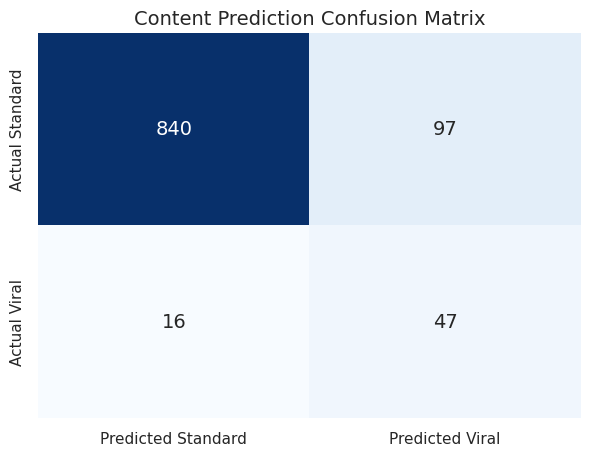

In [4]:
# Initialise and train the Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

print("Training Random Forest on SMOTE-balanced data...")
rf_classifier.fit(X_train_resampled, y_train_resampled)
print("✅ Model Training Complete.\n")

# Generate predictions
y_pred = rf_classifier.predict(X_test_scaled)
y_prob = rf_classifier.predict_proba(X_test_scaled)[:, 1]

print("--- ALGORITHMIC CLASSIFICATION REPORT ---\n")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Viral (1)']))

# Visualise the Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Standard', 'Predicted Viral'],
            yticklabels=['Actual Standard', 'Actual Viral'], cbar=False, annot_kws={"size": 14})
plt.title('Content Prediction Confusion Matrix', fontsize=14)
plt.show()

## 4. Algorithmic Transparency: SHAP Interpretability
A 'black-box' model is useless to a content strategy team. When the algorithm flags a video for the "For You" feed, strategists need to know *why*.

We utilise **SHAP (SHapley Additive exPlanations)** to break down the exact psychological and technical features that drove the algorithm to flag a video's viral potential.

Calculating SHAP values for algorithmic transparency...


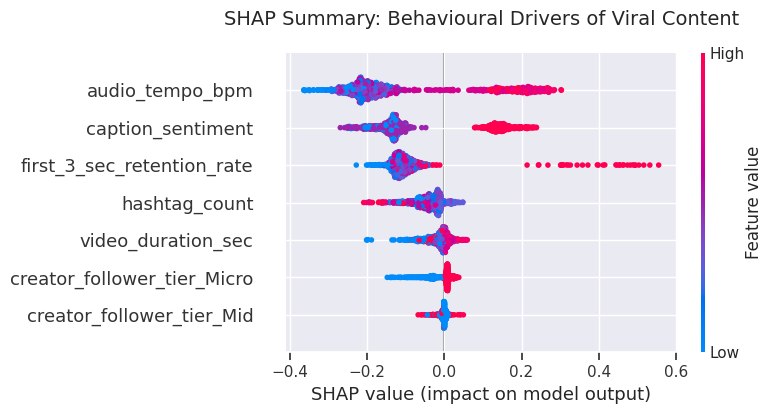

In [5]:
print("Calculating SHAP values for algorithmic transparency...")

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_scaled)

# Handle SHAP dimensionality depending on the library version
if isinstance(shap_values, list):
    shap_values_viral = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_values_viral = shap_values[:, :, 1]
    else:
        shap_values_viral = shap_values

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title('SHAP Summary: Behavioural Drivers of Viral Content', fontsize=14, pad=20)
shap.summary_plot(shap_values_viral, X_test_scaled, show=False)
plt.show()

## Conclusion
This Predictive Content Engagement pipeline successfully balances the highly skewed nature of viral vs. standard video traffic using SMOTE. By engineering features based on behavioral science, the ensemble model effectively identifies the mathematical signatures of high-engagement content.

Crucially, the **SHAP implementation** bridges the gap between Data Science and Content Strategy. As demonstrated in the summary plot, strategists can immediately see that a high `first_3_sec_retention_rate` and an upbeat `audio_tempo_bpm` are the primary psychological and technical drivers triggering viral potential.

This level of algorithmic transparency allows media companies and creators to move away from "guessing" what works and instead optimize their content strategies using predictive, human-centric data.